In [1]:
import pandas as pd
import numpy as np

## Intermediate state: This script is trying to cluster final loop calls after hiccups filtering between multiple samples and pick the representitive per cluster based on the max of sum of balanced counts as same as in our unionloops method

This idea was borrowed from the mariner, whose author is also the author of the Bond et al. We want to know if clustering those enriched pixels before filtering can better fine-tune loops per sample than clustering those final loop calls. The mariner was designed to cluster final loops calls from any loop callers and find the representatives.

In [2]:
# merged final dots file from section "Merge loops called from each individual library" in
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots=pd.read_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t')
dots.head()

,chrom1,start1,end1,chrom2,start2,end2,sample_name
0,chr10,32795000,32800000,chr10,33005000,33010000,K562_0000min&MEGA
1,chr10,30415000,30420000,chr10,30530000,30535000,K562_0000min&K562_4320min&MEGA
2,chr10,30390000,30395000,chr10,30590000,30595000,K562_0000min&K562_4320min&MEGA
3,chr10,35120000,35125000,chr10,35210000,35215000,K562_0000min&K562_0360min
4,chr10,28665000,28670000,chr10,28990000,28995000,K562_0000min&K562_0360min&K562_4320min&MEGA


In [3]:
# pick the representitive per cluster with the max of sum of balanced counts as same as in the unionloops.
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
merged_loops_path=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
resolution=5000
assembly_name='hg38'
output_centroids=dots_dir+'clustering_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
output_clusters=dots_dir+'clustering_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops/clusters_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops.py $input_cooler_paths $merged_loops_path $resolution $assembly_name $output_centroids $output_clusters"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <573709> is submitted to queue <long>.


## Mariner-style: This script is trying to cluster final loop calls after hiccups filtering between multiple samples and pick the representitive per cluster based on the max value at one condition instead of max of sum of balanced counts like our unionloops method.
Try to reproduce mariner: (1) cluster only final loops (2) select representative based on the max value at one condition. To fair compare to our unionloops, both use Birch clustering and 20kb cluster radius instead of using Mariner's DBSCAN clustering.

In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

In [2]:
# merged final dots file from section "Merge loops called from each individual library" in
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots=pd.read_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t')
dots.head()

,chrom1,start1,end1,chrom2,start2,end2,sample_name
0,chr10,32795000,32800000,chr10,33005000,33010000,K562_0000min&MEGA
1,chr10,30415000,30420000,chr10,30530000,30535000,K562_0000min&K562_4320min&MEGA
2,chr10,30390000,30395000,chr10,30590000,30595000,K562_0000min&K562_4320min&MEGA
3,chr10,35120000,35125000,chr10,35210000,35215000,K562_0000min&K562_0360min
4,chr10,28665000,28670000,chr10,28990000,28995000,K562_0000min&K562_0360min&K562_4320min&MEGA


In [20]:
# pick the representitive per cluster with the max value of balanced counts as same as in the mariner.
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
merged_loops_path=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
resolution=5000
assembly_name='hg38'
output_centroids=dots_dir+'cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_value_at_a_specific_sample_mariner_style/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
output_clusters=dots_dir+'cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_value_at_a_specific_sample_mariner_style/clusters_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_value_at_a_specific_sample_mariner_style.py $input_cooler_paths $merged_loops_path $resolution $assembly_name $output_centroids $output_clusters"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <675863> is submitted to queue <long>.


## Compare percentage of anchors overlapped with CNR peaks between (1) original final loops (HiCCUPS), (2) clustering final loops and pick representative with max value (Mariner-style), (3) clustering final loops and pick representative with max sum (intermediate state), and (4) clustering enriched pixels before filtering and pick representative with max sum (unionloops).

In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

In [2]:
cluster_file_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
cluster_new=pd.read_csv(cluster_file_new, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]

dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_old=pd.read_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t')
# remove MEGA only loops
dots_old=dots_old.loc[dots_old.sample_name != 'MEGA']

dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots_new=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
# remove MEGA only loops
dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

dots_file_old_no_filtering='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt'


In [3]:
dots_old_in_cluster_new=pd.merge(dots_old, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])
dots_new_in_cluster_new=pd.merge(dots_new, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])


overlapped_loops={}
for cond in conditions:
    overlapped_loops[cond]={}
    # left: old; right: new
    df=pd.merge(dots_old_in_cluster_new.loc[dots_old_in_cluster_new.sample_name.str.contains(cond)],
                dots_new_in_cluster_new.loc[dots_new_in_cluster_new.sample_name.str.contains(cond)],
                on=['region','c_label','c_size'],
                how="outer",
                indicator=True)
    
    # filtered loops (old)
    dots_old_no_filtering=pd.read_csv(dots_file_old_no_filtering, sep='\t')
    dots_old_no_filtering=dots_old_no_filtering.loc[dots_old_no_filtering.sample_name.str.contains(cond), ['chrom1','start1','end1','chrom2','start2','end2']]
    dots_old_no_filtering_in_cluster_new=pd.merge(dots_old_no_filtering, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])

    columns_to_convert=['start1','end1','start2','end2']
    
    df_old_only=df.loc[df._merge == 'left_only', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_old_only[columns_to_convert] = df_old_only[columns_to_convert].astype(int)
    overlapped_loops[cond]['old_only']=df_old_only
    
    df_new_only=df.loc[df._merge == 'right_only', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2', 'region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_new_only[columns_to_convert] = df_new_only[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_only_in_new']=df_new_only
    
    # find filtered loops (old) in new only clusters
    df_dots_old_no_filtering_in_new_only_clusters=pd.merge(dots_old_no_filtering_in_cluster_new, df_new_only, on=['region','c_label','c_size'])[['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert] = df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_only_in_old_no_filtering']=df_dots_old_no_filtering_in_new_only_clusters
    
    # multiple loops belong to the same cluster
    df_old_in_both=df.loc[df._merge == 'both', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_old_in_both[columns_to_convert] = df_old_in_both[columns_to_convert].astype(int)
    overlapped_loops[cond]['old_in_both']=df_old_in_both
    
    df_new_in_both=df.loc[df._merge == 'both', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_new_in_both[columns_to_convert] = df_new_in_both[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_in_both']=df_new_in_both
    

In [4]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
mariner_like_dots=dots_dir+'cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_value_at_a_specific_sample_mariner_style/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
mariner_like_dots=pd.read_csv(mariner_like_dots,sep='\t')
mariner_like_clusters=dots_dir+'cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_value_at_a_specific_sample_mariner_style/clusters_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
mariner_like_clusters=pd.read_csv(mariner_like_clusters,sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
# For a fair comparison, we can exclude hiccups (old) only loops since unionloops only removed a small number of singletons without shared anchors.
# e.g., overlapped_loops['K562_0000min']['old_only']
for cond in conditions:
    exclude_df=overlapped_loops[cond]['old_only'][['chrom1','start1','end1','chrom2','start2','end2']]
    exclude_clusters=pd.merge(exclude_df, mariner_like_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])[['region','c_label']]
    mariner_like_loops=mariner_like_dots.loc[mariner_like_dots.sample_name.str.contains(cond), ['chrom1','start1','end1','chrom2','start2','end2']]
    mariner_like_loops_in_cluster=pd.merge(mariner_like_loops, mariner_like_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])
    mariner_like_loops_in_cluster=pd.merge(mariner_like_loops_in_cluster, exclude_clusters, how='outer', indicator=True, on=['region','c_label'])
    mariner_like_loops_filtered=mariner_like_loops_in_cluster[mariner_like_loops_in_cluster['_merge'] == 'left_only']

    # IMPORTANT!!!
    # use overlapped_loops[cond]['old_in_both'] (hiccups without fine-tunning) as a reference, 
    # loops from all other three methods match to them (make sure same loci, i.e., within same cluster)
    hiccups_loops=overlapped_loops[cond]['old_in_both'].copy().drop(columns=['region', 'c_label', 'c_size'])
    matched_clusters=pd.merge(hiccups_loops, mariner_like_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])[['region','c_label']]
    matched_loops_filtered=pd.merge(mariner_like_loops_filtered, matched_clusters, on=['region','c_label'])
    overlapped_loops[cond]['mariner_like']=matched_loops_filtered
    


In [5]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
intermediate_state_dots=dots_dir+'clustering_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
intermediate_state_dots=pd.read_csv(intermediate_state_dots,sep='\t')
intermediate_state_clusters=dots_dir+'clustering_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops/clusters_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
intermediate_state_clusters=pd.read_csv(intermediate_state_clusters,sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
# For a fair comparison, we can exclude hiccups (old) only loops since unionloops only removed a small number of singletons without shared anchors.
# e.g., overlapped_loops['K562_0000min']['old_only']
for cond in conditions:
    exclude_df=overlapped_loops[cond]['old_only'][['chrom1','start1','end1','chrom2','start2','end2']]
    exclude_clusters=pd.merge(exclude_df, intermediate_state_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])[['region','c_label']]
    intermediate_state_loops=intermediate_state_dots.loc[intermediate_state_dots.sample_name.str.contains(cond), ['chrom1','start1','end1','chrom2','start2','end2']]
    intermediate_state_loops_in_cluster=pd.merge(intermediate_state_loops, intermediate_state_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])
    intermediate_state_loops_in_cluster=pd.merge(intermediate_state_loops_in_cluster, exclude_clusters, how='outer', indicator=True, on=['region','c_label'])
    intermediate_state_loops_filtered=intermediate_state_loops_in_cluster[intermediate_state_loops_in_cluster['_merge'] == 'left_only']

    # IMPORTANT!!!
    # use overlapped_loops[cond]['old_in_both'] (hiccups without fine-tunning) as a reference, 
    # loops from all other three methods match to them (make sure same loci, i.e., within same cluster)
    hiccups_loops=overlapped_loops[cond]['old_in_both'].copy().drop(columns=['region', 'c_label', 'c_size'])
    matched_clusters=pd.merge(hiccups_loops, intermediate_state_clusters, on=['chrom1','start1','end1','chrom2','start2','end2'])[['region','c_label']]
    matched_loops_filtered=pd.merge(intermediate_state_loops_filtered, matched_clusters, on=['region','c_label'])
    overlapped_loops[cond]['intermediate_state']=matched_loops_filtered
    

In [6]:
# merged peak files CNR (two replicates)

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}



In [7]:
# old_in_both: hiccups, new_in_both: unionloops
# Now for a fair comparison: use overlapped_loops[cond]['old_in_both'] (hiccups without fine-tunning) 
# as a reference, loops from all other three methods match to them (make sure same loci, i.e., within same cluster)
methods=['old_in_both', 'mariner_like', 'intermediate_state', 'new_in_both']

all_anchors=[]
for cond in conditions:
    for method in methods:
        loops_df=overlapped_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
        anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
        anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
        anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
        anchors['condition']=cond
        anchors['method']=method
        all_anchors.append(anchors)
        
all_anchors=pd.concat(all_anchors, ignore_index=True)

In [8]:
import bioframe
import pandas as pd
import numpy as np

def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    
    


In [9]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)



In [10]:
anchors_overlapped_with_CTCF_peaks

,condition,method,count,total,percent
0,K562_0000min,old_in_both,4003,7050,56.780142
1,K562_0000min,mariner_like,4155,6862,60.550860
2,K562_0000min,intermediate_state,4323,6825,63.340659
3,K562_0000min,new_in_both,4555,6868,66.322073
4,K562_0360min,old_in_both,2937,5412,54.268293
5,K562_0360min,mariner_like,3129,5228,59.850803
6,K562_0360min,intermediate_state,3250,5215,62.320230
7,K562_0360min,new_in_both,3486,5249,66.412650
8,K562_4320min,old_in_both,5570,9627,57.858107
9,K562_4320min,mariner_like,5547,9291,59.702938


In [11]:
anchors_overlapped_with_rad21_peaks

,condition,method,count,total,percent
0,K562_0000min,old_in_both,3536,7050,50.156028
1,K562_0000min,mariner_like,3616,6862,52.696007
2,K562_0000min,intermediate_state,3737,6825,54.754579
3,K562_0000min,new_in_both,3915,6868,57.003494
4,K562_4320min,old_in_both,3691,9627,38.340085
5,K562_4320min,mariner_like,3675,9291,39.554407
6,K562_4320min,intermediate_state,3741,9256,40.417027
7,K562_4320min,new_in_both,3913,9351,41.845792


In [12]:
anchors_overlapped_with_atac_peaks

,condition,method,count,total,percent
0,K562_0000min,old_in_both,3773,7050,53.517730
1,K562_0000min,mariner_like,3801,6862,55.392014
2,K562_0000min,intermediate_state,3852,6825,56.439560
3,K562_0000min,new_in_both,4022,6868,58.561444
4,K562_0360min,old_in_both,3058,5412,56.504065
5,K562_0360min,mariner_like,3084,5228,58.990054
6,K562_0360min,intermediate_state,3125,5215,59.923298
7,K562_0360min,new_in_both,3231,5249,61.554582
8,K562_4320min,old_in_both,6176,9627,64.152903
9,K562_4320min,mariner_like,6047,9291,65.084490


p_labels_hiccups_vs_mariner_like (per time point): ['*', '*', '*']
p_labels_mariner_like_vs_intermediate (per time point): ['*', '*', '*']
p_labels_intermediate_vs_unionloops (per time point): ['*', '*', '*']


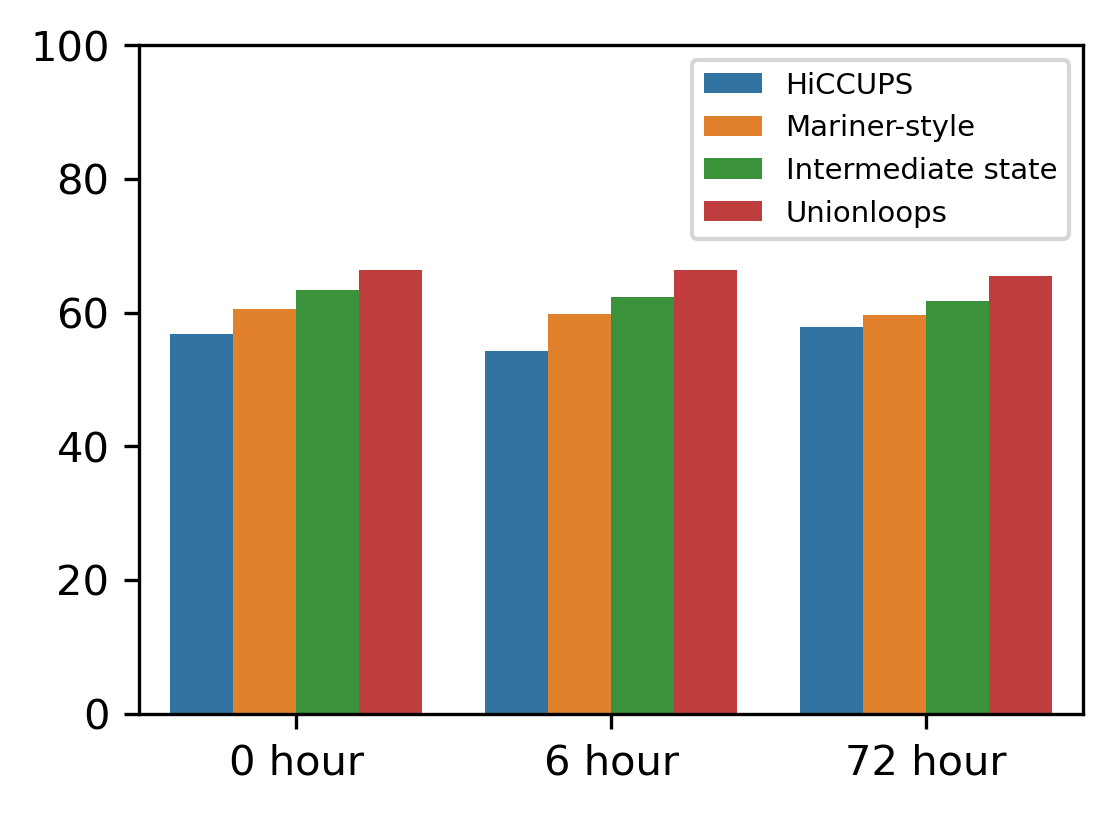

In [13]:
# CTCF
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_CTCF_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
# chi2 test (hiccups vs mariner_like)
p_labels_hiccups_vs_mariner_like=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_hiccups_vs_mariner_like.append(p_label)

# chi2 test (mariner_like vs intermediate)
p_labels_mariner_like_vs_intermediate=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_like_vs_intermediate.append(p_label)

# chi2 test (intermediate vs unionloops)
p_labels_intermediate_vs_unionloops=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_intermediate_vs_unionloops.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with CTCF CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['HiCCUPS', 'Mariner-style', 'Intermediate state', 'Unionloops'], loc='upper right', fontsize=7)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S7/bar_plot_of_percentage_of_5kb_anchors_of_hiccups_mariner_style_intermediate_state_and_unionloops_overlapped_with_CTCF_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_hiccups_vs_mariner_like (per time point): {p_labels_hiccups_vs_mariner_like}')
print(f'p_labels_mariner_like_vs_intermediate (per time point): {p_labels_mariner_like_vs_intermediate}')
print(f'p_labels_intermediate_vs_unionloops (per time point): {p_labels_intermediate_vs_unionloops}')

p_labels_hiccups_vs_mariner_like (per time point): ['*', 'ns']
p_labels_mariner_like_vs_intermediate (per time point): ['*', 'ns']
p_labels_intermediate_vs_unionloops (per time point): ['*', '*']


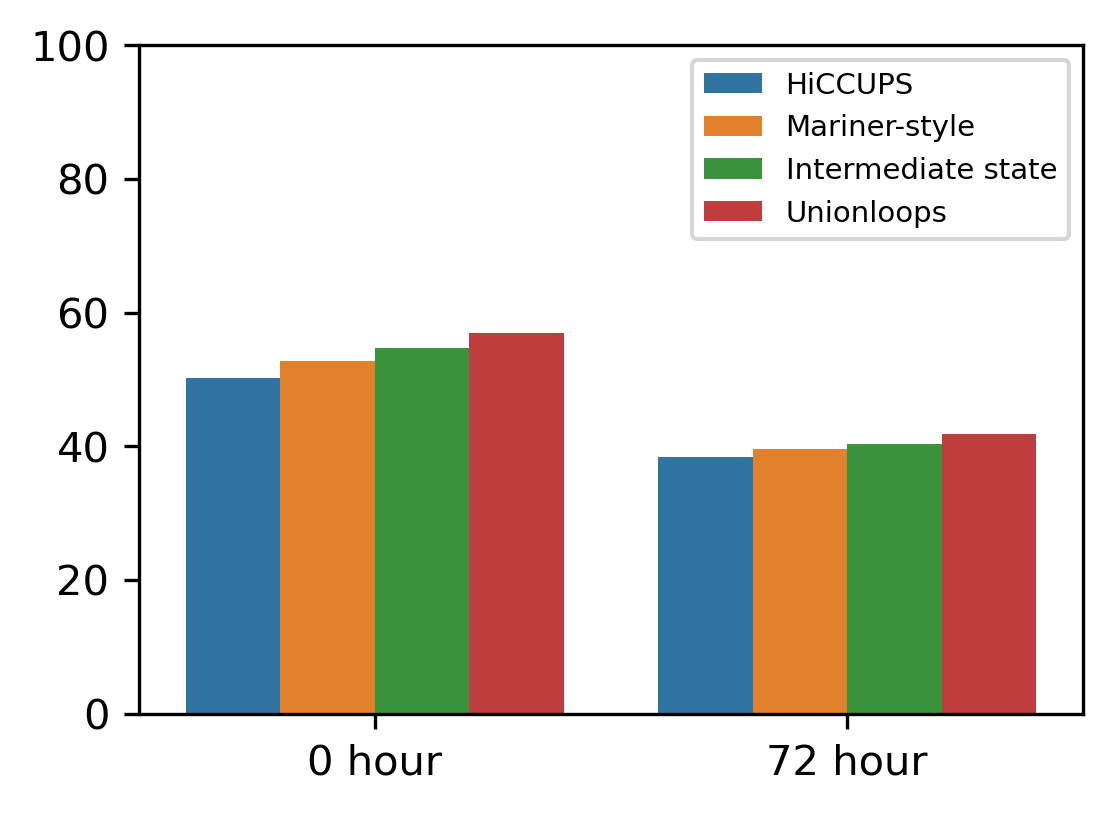

In [14]:
# rad21
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_rad21_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

conditions=['K562_0000min',
            'K562_4320min']
# chi2 test (hiccups vs mariner_like)
p_labels_hiccups_vs_mariner_like=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_hiccups_vs_mariner_like.append(p_label)

# chi2 test (mariner_like vs intermediate)
p_labels_mariner_like_vs_intermediate=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_like_vs_intermediate.append(p_label)

# chi2 test (intermediate vs unionloops)
p_labels_intermediate_vs_unionloops=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_intermediate_vs_unionloops.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with rad21 CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['HiCCUPS', 'Mariner-style', 'Intermediate state', 'Unionloops'], loc='upper right', fontsize=7)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S7/bar_plot_of_percentage_of_5kb_anchors_of_hiccups_mariner_style_intermediate_state_and_unionloops_overlapped_with_Rad21_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_hiccups_vs_mariner_like (per time point): {p_labels_hiccups_vs_mariner_like}')
print(f'p_labels_mariner_like_vs_intermediate (per time point): {p_labels_mariner_like_vs_intermediate}')
print(f'p_labels_intermediate_vs_unionloops (per time point): {p_labels_intermediate_vs_unionloops}')

p_labels_hiccups_vs_mariner_like (per time point): ['*', '*', 'ns']
p_labels_mariner_like_vs_intermediate (per time point): ['ns', 'ns', 'ns']
p_labels_intermediate_vs_unionloops (per time point): ['*', 'ns', 'ns']


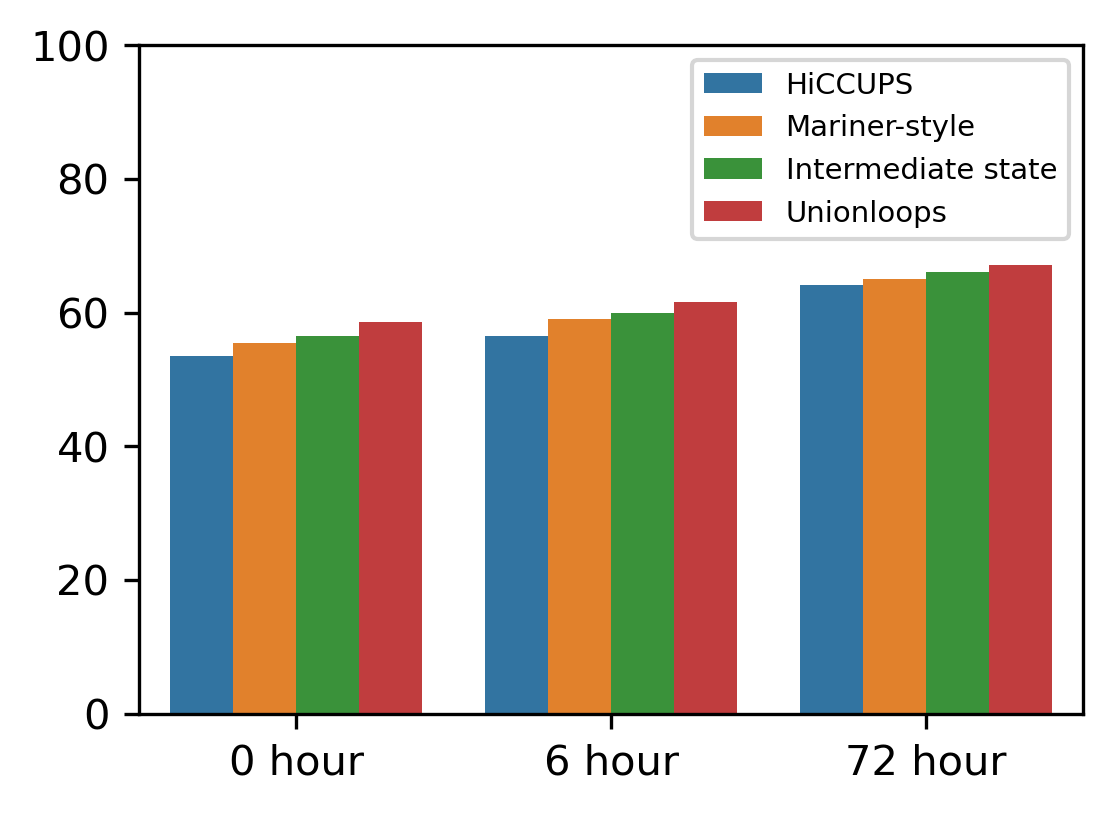

In [15]:
# atac
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_atac_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
# chi2 test (hiccups vs mariner_like)
p_labels_hiccups_vs_mariner_like=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_hiccups_vs_mariner_like.append(p_label)

# chi2 test (mariner_like vs intermediate)
p_labels_mariner_like_vs_intermediate=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_like_vs_intermediate.append(p_label)

# chi2 test (intermediate vs unionloops)
p_labels_intermediate_vs_unionloops=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_intermediate_vs_unionloops.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with atac CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['HiCCUPS', 'Mariner-style', 'Intermediate state', 'Unionloops'], loc='upper right', fontsize=7)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S7/bar_plot_of_percentage_of_5kb_anchors_of_hiccups_mariner_style_intermediate_state_and_unionloops_overlapped_with_ATAC_Seq_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_hiccups_vs_mariner_like (per time point): {p_labels_hiccups_vs_mariner_like}')
print(f'p_labels_mariner_like_vs_intermediate (per time point): {p_labels_mariner_like_vs_intermediate}')
print(f'p_labels_intermediate_vs_unionloops (per time point): {p_labels_intermediate_vs_unionloops}')

## Original SIP loops (from authors) VS Mariner-fine-tuned SIP loops VS UnionLoops-fine-tuned SIP loops (Note: all same loci for a fair comparison of their precision)

SIP: 5kb loops <br>
Mariner fine-tuned SIP: for clustering: Manhattan distance, DBSCAN clustering, radius=10kb, pick max value (SIP metric ('APScoreAvg')) in one single sample per cluster) <br>
UionLoops (based on HiCCUPS): for clustering: Euclidean distance, clustering used by HiCCUPS, radius=20kb, pick max sum value (UnionLoops metric ('balanced counts')) across multiple samples per cluster)

### Generate mariner fine-tuned SIP loops

In [1]:
# # Run on local laptop (R)
# #!/usr/bin/env Rscript


# # https://genome.cshlp.org/content/suppl/2023/09/12/gr.277397.122.DC1
# # https://genome.cshlp.org/content/suppl/2023/09/12/gr.277397.122.DC1/Supplemental_Code.zip
# # radius = 2, column = "APScoreAvg", same as ctcfLoops.R (2 bins radius)
# # analysis/ctcfLoops.R
# # R -q -e "library(mariner); packageVersion('mariner'); sessionInfo()"
# # conda env: mariner-r44
# # Four loop list from author email:
# # Subject: Questions about in situ Hi-C data during differentiation of K562 cells at 0, 6, and 72 h.

# library(mariner)

# file0    <- "K562_0h_SIP_5kbLoops.txt"
# file6    <- "K562_6h_SIP_5kbLoops.txt"
# file72   <- "K562_72h_SIP_5kbLoops.txt"
# fileMega <- "K562_Mega_SIP_5kbLoops.txt"


# # Read them in
# loops <- list(
#   read.table(file0,    header = TRUE),
#   read.table(file6,    header = TRUE),
#   read.table(file72,   header = TRUE),
#   read.table(fileMega, header = TRUE)
# )

# loops <- lapply(loops, function(df) {
#   # Convert to character (safe if numeric)
#   c1 <- as.character(df$chromosome1)
#   c2 <- as.character(df$chromosome2)
  
#   # Add "chr" only if not already present
#   df$chromosome1 <- ifelse(grepl("^chr", c1), c1, paste0("chr", c1))
#   df$chromosome2 <- ifelse(grepl("^chr", c2), c2, paste0("chr", c2))
  
#   return(df)
# })

# names(loops) <- c("0", "6", "72", "mega")

# # Assign row names
# for (i in 1:length(loops)){
#   loops[[i]]$name <- paste0("loop", 1:nrow(loops[[i]]))
# }

# # Convert to ginteractions: 
# loops <- lapply(loops, as_ginteractions)

# # Merge loops within 2 bins radius
# mp <-
#   mergePairs(x = loops,
#              radius=10e3, # 2*5kb resolution
#              column="APScoreAvg",
#              selectMax=TRUE)

# #get loops identified in at least each timepoint
# in0 <- subsetBySource(mp, include = "0")
# in6 <- subsetBySource(mp, include = "6")
# in72 <- subsetBySource(mp, include = "72")


# ## Export each subset as TSV (BEDPE-style + metadata)
# to_tsv <- function(x, file) {
#   df <- as.data.frame(x)
#   write.table(df, file = file, sep = "\t", quote = FALSE, row.names = FALSE)
# }

# to_tsv(in0,  "mariner_loops_in0.tsv")
# to_tsv(in6,  "mariner_loops_in6.tsv")
# to_tsv(in72, "mariner_loops_in72.tsv")

# ## extract corresponding clusters
# clusters=as.data.frame(getPairClusters(mp[1])[[1]])
# clusters$cluster_id=1
# for(i in 2:nrow(as.data.frame(mp))){
#   cluster_df=as.data.frame(getPairClusters(mp[i])[[1]])
#   cluster_df$cluster_id=i
#   clusters=rbind(clusters,cluster_df)
# }

# write.table(clusters, file = "mariner_clusters.tsv", sep = "\t", quote = FALSE, row.names = FALSE)

# ## Save sessionInfo to a single text file
# writeLines(capture.output(sessionInfo()), "sessionInfo.txt")

# # output files were saved to /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/




# # sessionInfo.txt

# R version 4.4.3 (2025-02-28)
# Platform: x86_64-apple-darwin13.4.0
# Running under: macOS Big Sur ... 10.16

# Matrix products: default
# BLAS/LAPACK: /opt/miniconda3/envs/mariner-r44/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

# locale:
# [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

# time zone: America/New_York
# tzcode source: system (macOS)

# attached base packages:
# [1] stats     graphics  grDevices utils     datasets  methods   base     

# other attached packages:
# [1] mariner_1.6.0

# loaded via a namespace (and not attached):
#  [1] SummarizedExperiment_1.36.0 gtable_0.3.6               
#  [3] rjson_0.2.23                ggplot2_3.5.2              
#  [5] plyranges_1.26.0            rhdf5_2.50.0               
#  [7] Biobase_2.66.0              lattice_0.22-7             
#  [9] bitops_1.0-9                rhdf5filters_1.18.0        
# [11] vctrs_0.6.5                 tools_4.4.3                
# [13] generics_0.1.4              yulab.utils_0.2.1          
# [15] stats4_4.4.3                curl_7.0.0                 
# [17] parallel_4.4.3              tibble_3.3.0               
# [19] pkgconfig_2.0.3             Matrix_1.7-3               
# [21] data.table_1.17.8           ggplotify_0.1.2            
# [23] plotgardener_1.12.0         RColorBrewer_1.1-3         
# [25] S4Vectors_0.44.0            assertthat_0.2.1           
# [27] lifecycle_1.0.4             GenomeInfoDbData_1.2.13    
# [29] compiler_4.4.3              farver_2.1.2               
# [31] progress_1.2.3              Rsamtools_2.22.0           
# [33] Biostrings_2.74.0           codetools_0.2-20           
# [35] InteractionSet_1.34.0       GenomeInfoDb_1.42.0        
# [37] yaml_2.3.10                 RCurl_1.98-1.17            
# [39] pillar_1.11.0               crayon_1.5.3               
# [41] colourvalues_0.3.9          BiocParallel_1.40.0        
# [43] DelayedArray_0.32.0         dbscan_1.2.3               
# [45] abind_1.4-5                 tidyselect_1.2.1           
# [47] digest_0.6.37               purrr_1.1.0                
# [49] restfulr_0.0.16             dplyr_1.1.4                
# [51] grid_4.4.3                  colorspace_2.1-1           
# [53] cli_3.6.5                   SparseArray_1.6.0          
# [55] magrittr_2.0.3              S4Arrays_1.6.0             
# [57] XML_3.99-0.17               withr_3.0.2                
# [59] prettyunits_1.2.0           rappdirs_0.3.3             
# [61] UCSC.utils_1.2.0            scales_1.4.0               
# [63] XVector_0.46.0              httr_1.4.7                 
# [65] matrixStats_1.5.0           hms_1.1.3                  
# [67] HDF5Array_1.34.0            BiocIO_1.16.0              
# [69] GenomicRanges_1.58.0        IRanges_2.40.0             
# [71] rtracklayer_1.66.0          gridGraphics_0.5-1         
# [73] rlang_1.1.6                 Rcpp_1.1.0                 
# [75] glue_1.8.0                  BiocManager_1.30.26        
# [77] BiocGenerics_0.52.0         jsonlite_2.0.0             
# [79] strawr_0.0.92               R6_2.6.1                   
# [81] Rhdf5lib_1.28.0             GenomicAlignments_1.42.0   
# [83] MatrixGenerics_1.18.0       fs_1.6.6                   
# [85] zlibbioc_1.52.0            




### Generate UnionLoops-fined-tuned SIP loops
This script is trying to cluster final loop calls (for any loop callers, here for SIP loops) between multiple samples and pick the representitive per cluster based on the max of sum of balanced counts as same as in our unionloops method. (same for above intermediate state)

#### Merge loops called from each individual library (by exactly overlapping)

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min',
            'MEGA']

sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
# original_sip
original_sip_files={'K562_0000min': sip_dir+'K562_0h_SIP_5kbLoops.txt',
                    'K562_0360min': sip_dir+'K562_6h_SIP_5kbLoops.txt',
                    'K562_4320min': sip_dir+'K562_72h_SIP_5kbLoops.txt',
                    'MEGA': sip_dir+'K562_Mega_SIP_5kbLoops.txt'}

In [3]:
dots_list=[]
for cond in conditions:
    original_sip_df = pd.read_csv(
        original_sip_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    original_sip_df['chrom1']='chr'+original_sip_df['chrom1']
    original_sip_df['chrom2']='chr'+original_sip_df['chrom2']
    original_sip_df['sample_name']=cond
    dots_list.append(original_sip_df)
dots=pd.concat(dots_list).reset_index(drop=True)

merged_dots=dots.groupby(['chrom1','start1','end1','chrom2','start2','end2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()


In [4]:
merged_dots

,chrom1,start1,end1,chrom2,start2,end2,sample_name
0,chr1,640000,645000,chr1,860000,865000,K562_4320min
1,chr1,645000,650000,chr1,850000,855000,MEGA
2,chr1,660000,665000,chr1,850000,855000,K562_0000min
3,chr1,1030000,1035000,chr1,1250000,1255000,MEGA
4,chr1,1115000,1120000,chr1,1250000,1255000,K562_4320min&MEGA
...,...,...,...,...,...,...,...
38259,chrX,155525000,155530000,chrX,155815000,155820000,K562_0360min
38260,chrX,155545000,155550000,chrX,155720000,155725000,K562_4320min
38261,chrX,155640000,155645000,chrX,155955000,155960000,K562_0360min&MEGA
38262,chrX,155885000,155890000,chrX,156010000,156015000,K562_0000min


In [5]:
# merged_dots.to_csv(sip_dir+'union_dot_list_of_Bond_et_al_2023_5kb_original_SIP.txt', sep='\t', index=False, header=True)


In [1]:
# pick the representitive per cluster with the max of sum of balanced counts as same as in the unionloops.
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
merged_loops_path=sip_dir+'union_dot_list_of_Bond_et_al_2023_5kb_original_SIP.txt'
resolution=5000
assembly_name='hg38'
output_centroids=sip_dir+'clustering_original_SIP_loops_and_pick_its_centroid_based_on_max_sum_in_unionloops/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
output_clusters=sip_dir+'clustering_original_SIP_loops_and_pick_its_centroid_based_on_max_sum_in_unionloops/clusters_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/cluster_those_final_loops_after_filtering_and_pick_its_centroid_based_on_max_sum_in_unionloops.py $input_cooler_paths $merged_loops_path $resolution $assembly_name $output_centroids $output_clusters"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <96648> is submitted to queue <long>.


### Compare precision of original SIP loops (from authors) VS Mariner-fine-tuned SIP loops VS UnionLoops-fine-tuned SIP loops

In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

In [2]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
# original_sip
original_sip_files={'K562_0000min': sip_dir+'K562_0h_SIP_5kbLoops.txt',
                    'K562_0360min': sip_dir+'K562_6h_SIP_5kbLoops.txt',
                    'K562_4320min': sip_dir+'K562_72h_SIP_5kbLoops.txt'}

# mariner_sip
mariner_sip_files={'K562_0000min': sip_dir+'mariner_loops_in0.tsv',
                   'K562_0360min': sip_dir+'mariner_loops_in6.tsv',
                   'K562_4320min': sip_dir+'mariner_loops_in72.tsv'}
mariner_sip_clusters=pd.read_csv(sip_dir+'mariner_clusters.tsv', sep='\t')[['seqnames1','start1','end1','seqnames2','start2','end2','src','cluster_id']].rename({'seqnames1': 'chrom1', 'seqnames2': 'chrom2'}, axis='columns')

# UnionLoops_sip
dots_file=sip_dir+'clustering_original_SIP_loops_and_pick_its_centroid_based_on_max_sum_in_unionloops/centroids_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt'
dots_new=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
# remove MEGA only loops
dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']


In [3]:
# intersect original sip and unionloops first
# further intersect with mariner-sip loops
summary_loops={}
for cond in conditions:
    summary_loops[cond]={}
    # original sip
    original_sip_df = pd.read_csv(
        original_sip_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    original_sip_df['chrom1']='chr'+original_sip_df['chrom1']
    original_sip_df['chrom2']='chr'+original_sip_df['chrom2']
    
    # mariner sip
    mariner_sip_df = pd.read_csv(
        mariner_sip_files[cond],
        usecols=[0,1,2,5,6,7],
        header=0,
        sep='\t')
    mariner_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    
    # unionloops sip
    dots_new_df=dots_new.loc[dots_new.sample_name.str.contains(cond)]
    
    summary_loops[cond]['original_sip']=original_sip_df
    summary_loops[cond]['mariner_sip']=mariner_sip_df
    summary_loops[cond]['unionloops_sip']=dots_new_df
    
    

In [4]:
# merged peak files CNR (two replicates)

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}



In [5]:
methods=['original_sip',
         'mariner_sip',
         'unionloops_sip']

all_anchors=[]
for cond in conditions:
    for method in methods:
        loops_df=summary_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
        anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
        anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
        anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
        anchors['condition']=cond
        anchors['method']=method
        all_anchors.append(anchors)
        
all_anchors=pd.concat(all_anchors, ignore_index=True)

In [6]:
import bioframe
import pandas as pd
import numpy as np

def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    
    


In [7]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)


In [8]:
anchors_overlapped_with_CTCF_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,8686,19578,44.366125
1,K562_0000min,mariner_sip,8921,19400,45.984536
2,K562_0000min,unionloops_sip,9323,19094,48.826857
3,K562_0360min,original_sip,7355,18799,39.124422
4,K562_0360min,mariner_sip,7695,18519,41.551920
5,K562_0360min,unionloops_sip,8130,18145,44.805732
6,K562_4320min,original_sip,11389,24292,46.883748
7,K562_4320min,mariner_sip,11475,24219,47.380156
8,K562_4320min,unionloops_sip,11705,23845,49.087859


In [9]:
anchors_overlapped_with_rad21_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,7517,19578,38.395137
1,K562_0000min,mariner_sip,7716,19400,39.773196
2,K562_0000min,unionloops_sip,7952,19094,41.646591
3,K562_4320min,original_sip,7118,24292,29.301828
4,K562_4320min,mariner_sip,7164,24219,29.580082
5,K562_4320min,unionloops_sip,7175,23845,30.090166


In [10]:
anchors_overlapped_with_atac_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,7978,19578,40.749821
1,K562_0000min,mariner_sip,8080,19400,41.649485
2,K562_0000min,unionloops_sip,8228,19094,43.092071
3,K562_0360min,original_sip,7867,18799,41.847971
4,K562_0360min,mariner_sip,7967,18519,43.020681
5,K562_0360min,unionloops_sip,8090,18145,44.585285
6,K562_4320min,original_sip,12974,24292,53.408530
7,K562_4320min,mariner_sip,12996,24219,53.660349
8,K562_4320min,unionloops_sip,13048,23845,54.720067


p_labels_original_sip_vs_mariner_sip (per time point): ['*', '*', 'ns']
p_labels_mariner_sip_vs_unionloops_sip (per time point): ['*', '*', '*']
p_labels_original_sip_vs_unionloops_sip (per time point): ['*', '*', '*']


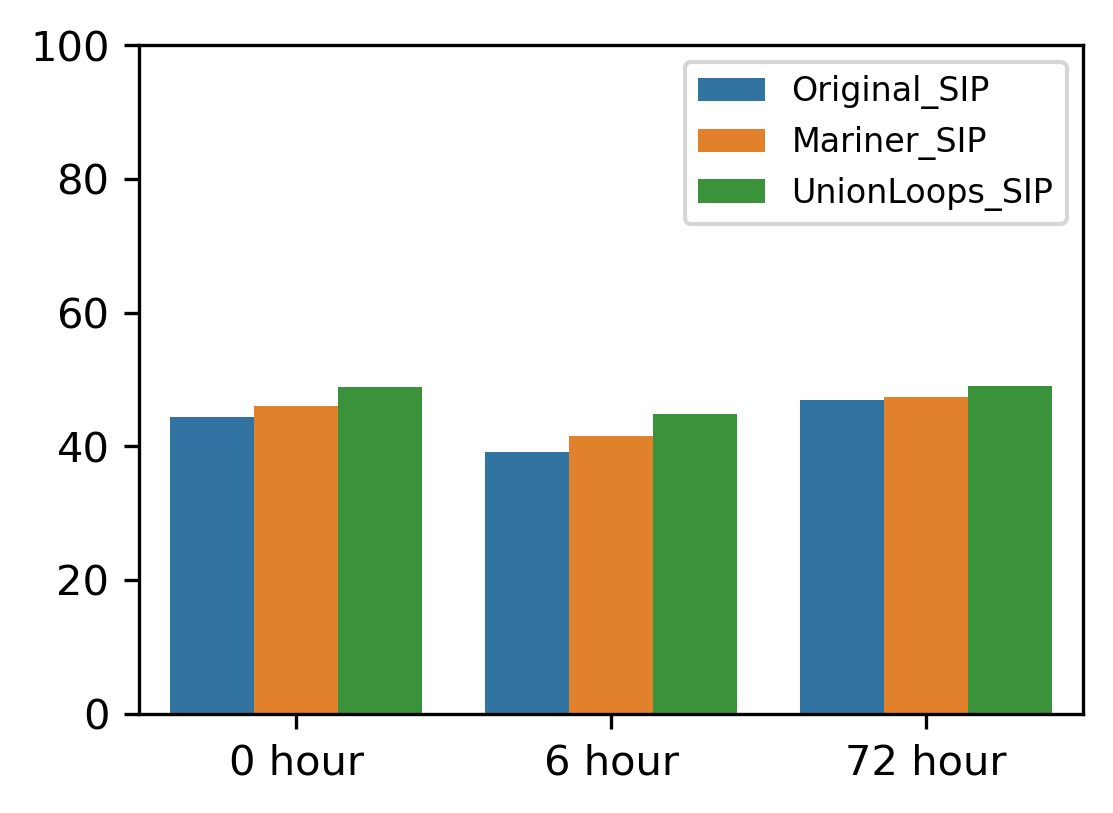

In [11]:
# CTCF
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_CTCF_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)
    
# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with CTCF CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_CTCF_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops_sip (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops_sip (per time point): {p_labels_original_sip_vs_unionloops_sip}')


p_labels_original_sip_vs_mariner_sip (per time point): ['*', 'ns']
p_labels_mariner_sip_vs_unionloops_sip (per time point): ['*', 'ns']
p_labels_original_sip_vs_unionloops_sip (per time point): ['*', 'ns']


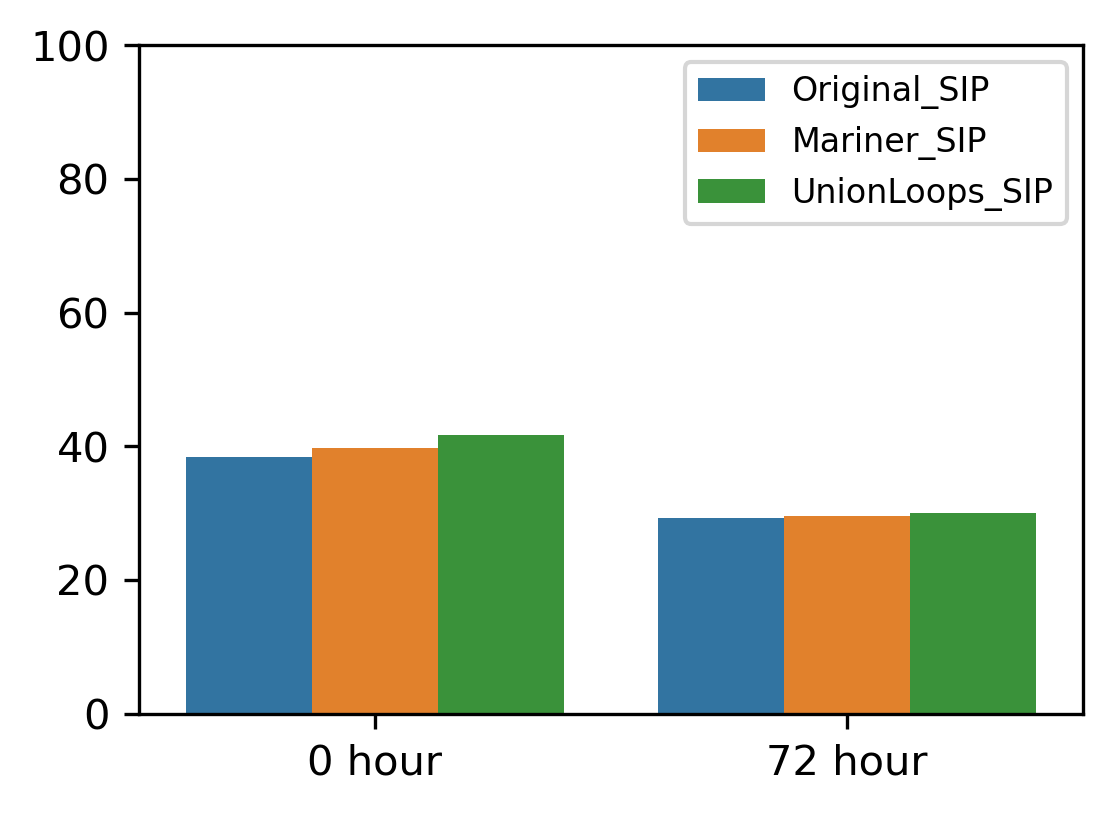

In [12]:
# rad21
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_rad21_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)
    
# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with rad21 CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)


# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_Rad21_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')



print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops_sip (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops_sip (per time point): {p_labels_original_sip_vs_unionloops_sip}')


p_labels_original_sip_vs_mariner_sip (per time point): ['ns', '*', 'ns']
p_labels_mariner_sip_vs_unionloops (per time point): ['*', '*', '*']
p_labels_original_sip_vs_unionloops (per time point): ['*', '*', '*']


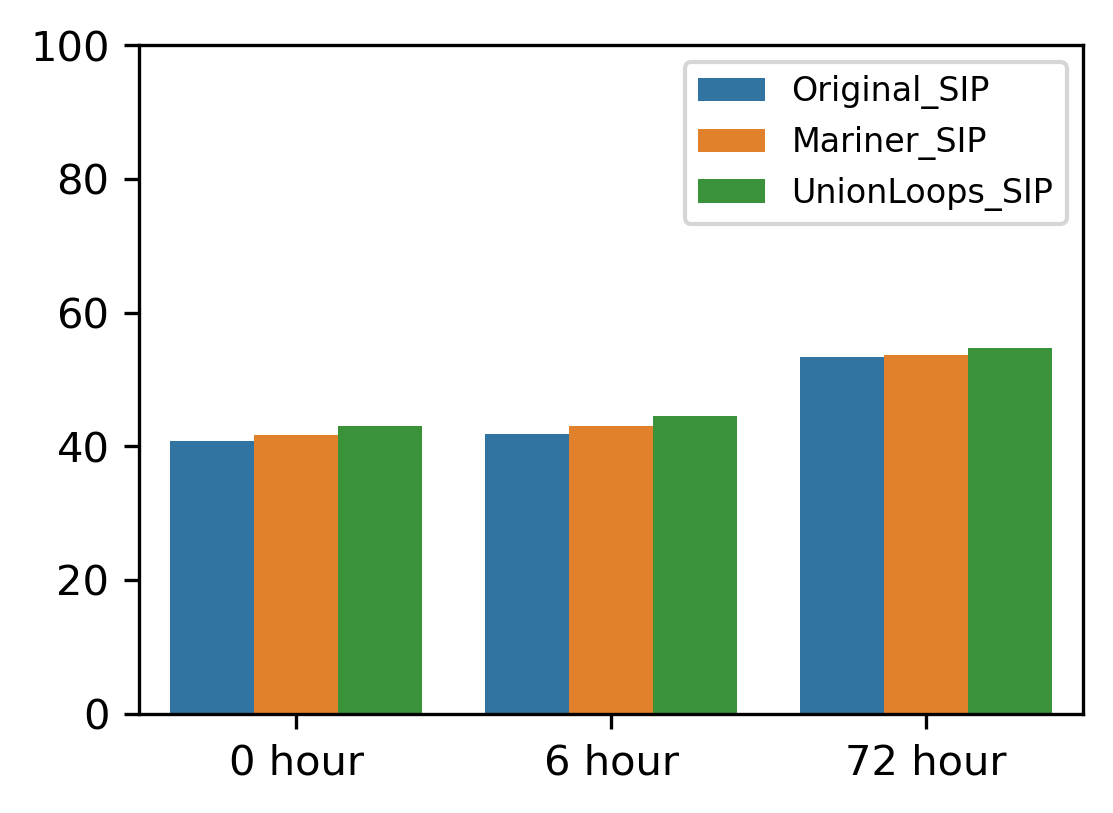

In [13]:
# atac
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_atac_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)

# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with atac CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)


# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_ATAC_Seq_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops (per time point): {p_labels_original_sip_vs_unionloops_sip}')
